In [2]:
import pandas as pd
import matplotlib.pyplot as plt

dir_2019_train = r'D:\DL\2019\LA\ASVspoof2019_LA_cm_protocols\ASVspoof2019.LA.cm.train.trn.txt'
dir_2019_dev = r'D:\DL\2019\LA\ASVspoof2019_LA_cm_protocols\ASVspoof2019.LA.cm.dev.trl.txt'
dir_2019_eval = r'D:\DL\2019\LA\ASVspoof2019_LA_cm_protocols\ASVspoof2019.LA.cm.eval.trl.txt'
dir_2021_eval_meta = r'D:\DL\2021\keys\LA\CM\trial_metadata.txt'

In [3]:
df_train = pd.read_csv(dir_2019_train, sep=' ', header=None, names=['speaker', 'filename', 'empty', 'attack', 'label'])
df_dev = pd.read_csv(dir_2019_dev, sep=' ', header=None, names=['speaker', 'filename', 'empty', 'attack', 'label'])
df_eval_19 = pd.read_csv(dir_2019_eval, sep=' ', header=None, names=['speaker', 'filename', 'empty', 'attack', 'label'])

df_meta_21 = pd.read_csv(dir_2021_eval_meta, sep=r'\s+', header=None)
labels_21 = []
for _, row in df_meta_21.iterrows():
    for val in row.dropna():
        if str(val).strip() in ['bonafide', 'spoof']:
            labels_21.append(str(val).strip())
            break

df_eval_21 = pd.DataFrame({'label': labels_21})

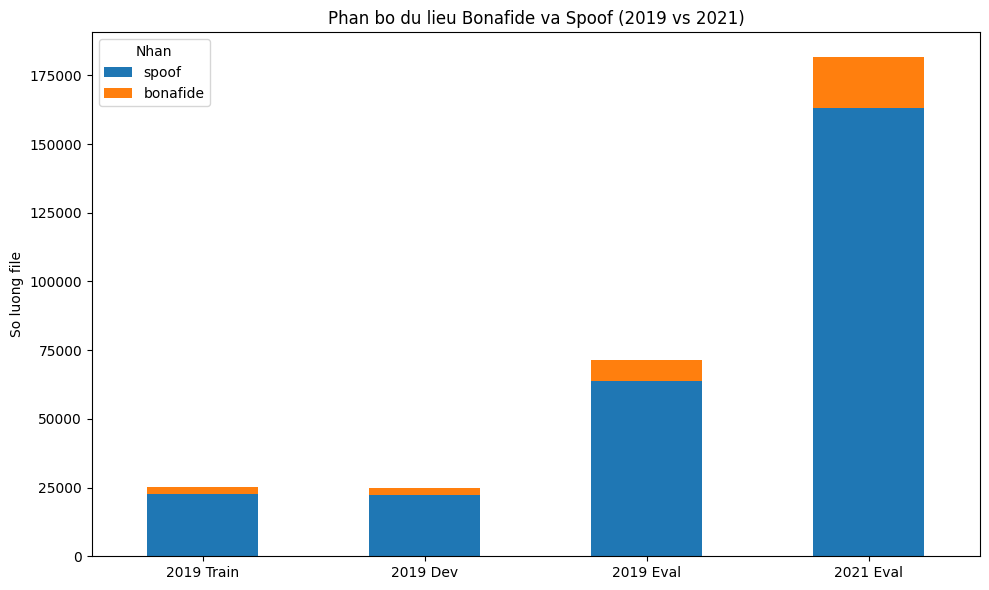

In [4]:
data_counts = {
    '2019 Train': df_train['label'].value_counts(),
    '2019 Dev': df_dev['label'].value_counts(),
    '2019 Eval': df_eval_19['label'].value_counts(),
    '2021 Eval': df_eval_21['label'].value_counts()
}

df_plot = pd.DataFrame(data_counts).T
df_plot.to_csv('thong_ke_du_lieu.csv')

df_plot.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Phan bo du lieu Bonafide va Spoof (2019 vs 2021)')
plt.ylabel('So luong file')
plt.xticks(rotation=0)
plt.legend(title='Nhan')
plt.tight_layout()
plt.show()